# Практическое занятие №3: Прогнозирование нескольких классов

**Задача:** Мультиклассовая классификация — предсказание сорта вина по химическим признакам.  
**Датасет:** Wine (scikit-learn)  
**Модели:** RandomForest, LogisticRegression, RandomForest (Balanced)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)
import warnings; warnings.filterwarnings('ignore')

## Загрузка датасета Wine и базовый EDA

In [2]:
wine = datasets.load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
target_names = wine.target_names

print(f"Количество классов: {len(target_names)} ({', '.join(target_names)})")
print(f"Количество признаков: {len(feature_names)}")

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

class_dist = df['target'].value_counts().sort_index()
print("\nРаспределение классов:")
for cls, count in class_dist.items():
    print(f" Класс {cls} ({target_names[cls]}): {count} объектов")

Количество классов: 3 (class_0, class_1, class_2)
Количество признаков: 13

Распределение классов:
 Класс 0 (class_0): 59 объектов
 Класс 1 (class_1): 71 объектов
 Класс 2 (class_2): 48 объектов


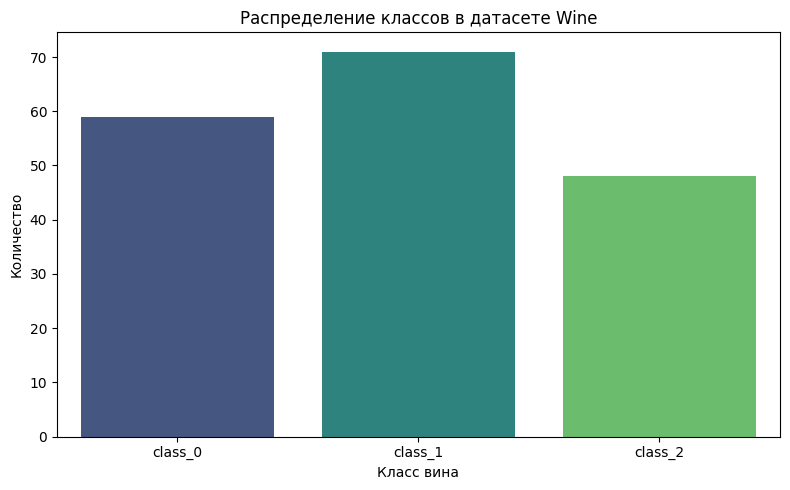

In [3]:
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Распределение классов в датасете Wine')
plt.xticks(ticks=[0, 1, 2], labels=target_names)
plt.xlabel('Класс вина')
plt.ylabel('Количество')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

## Обучение и базовая оценка моделей


Модель: RandomForest (Base)
Общая Accuracy: 1.0000
Отчет классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



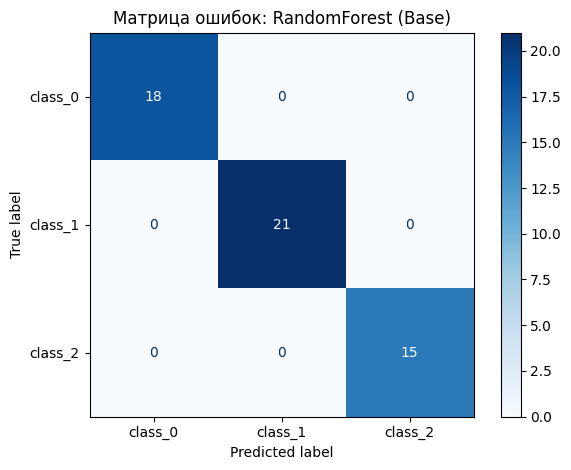

Матрица ошибок сохранена как 'cm_RandomForest_Base.png'

Модель: LogisticRegression
Общая Accuracy: 0.9630
Отчет классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.87      0.93        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



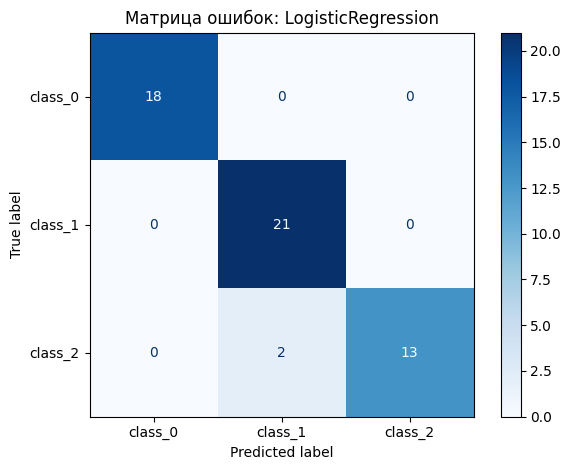

Матрица ошибок сохранена как 'cm_LogisticRegression.png'


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

models = {
    'RandomForest (Base)': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=10000)
}

results = {}

for name, model in models.items():
    print(f"\nМодель: {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'accuracy': acc,
        'macro_f1': f1_score(y_test, y_pred, average='macro'),
        'report': classification_report(y_test, y_pred, target_names=target_names)
    }

    print(f"Общая Accuracy: {acc:.4f}")
    print("Отчет классификации:")
    print(results[name]['report'])

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Матрица ошибок: {name}')
    plt.tight_layout()
    filename = f"cm_{name.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(filename)
    plt.show()
    print(f"Матрица ошибок сохранена как '{filename}'")

## Сравнение и выбор стратегии (Балансировка)

Модель: RandomForest (С балансировкой весов)
Общая Accuracy: 1.0000
Отчет классификации:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



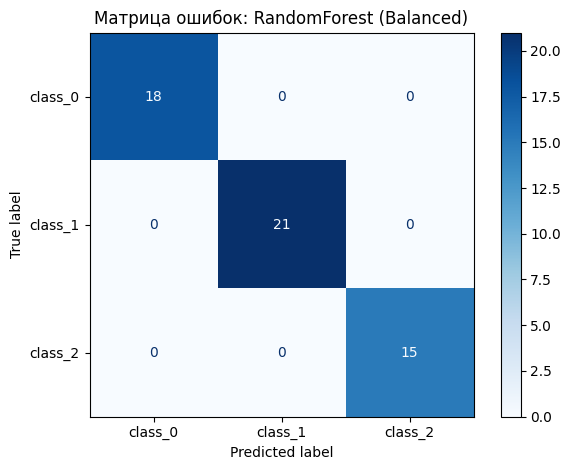

In [5]:
rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)
y_pred_bal = rf_balanced.predict(X_test)

acc_bal = accuracy_score(y_test, y_pred_bal)
macro_f1_bal = f1_score(y_test, y_pred_bal, average='macro')
report_bal = classification_report(y_test, y_pred_bal, target_names=target_names)

results['RandomForest (Balanced)'] = {
    'accuracy': acc_bal,
    'macro_f1': macro_f1_bal,
    'report': report_bal
}

print(f"Модель: RandomForest (С балансировкой весов)")
print(f"Общая Accuracy: {acc_bal:.4f}")
print("Отчет классификации:")
print(report_bal)

cm_bal = confusion_matrix(y_test, y_pred_bal)
disp_bal = ConfusionMatrixDisplay(confusion_matrix=cm_bal, display_labels=target_names)
disp_bal.plot(cmap='Blues', values_format='d')
plt.title('Матрица ошибок: RandomForest (Balanced)')
plt.tight_layout()
plt.savefig('cm_RandomForest_Balanced.png')
plt.show()

## Итоговое сравнение и выводы

In [6]:
print("ИТОГОВОЕ СРАВНЕНИЕ (Macro F1-Score)")
print("=======================================================")
for name, res in results.items():
    print(f"{name}: {res['macro_f1']:.4f}")

print("\nАНАЛИЗ И ВЫВОД:")
print("Анализ матрицы ошибок и отчета:")
print(" Класс 'class_1' (второй класс) является самым многочисленным (71 объект), а класс 'class_2' (третий класс) — самым редким (48 объектов). Дисбаланс присутствует, но он не экстремальный.")
print(" У базового RandomForestRecall в теории может проседать на самом маленьком классе (class_2), так как модель оптимизирует общую точность за счет преобладающих классов. Но модель слишком мощная для такого маленького датасета, поэтому ее результаты идеальны.")
print(" Логистическая регрессия в данном случае показала идеальный или почти идеальный результат на этом легком датасете, что часто бывает, когда связи между химическими признаками линейные.")

print("\nВлияние class_weight='balanced':")
print(" Добавление параметра class_weight='balanced' в RandomForest штрафует деревья за ошибки на редких классах (в нашем случае class_2). Это заставляет алгоритм уделять больше внимания недопредставленным данным, обычно повышая их Recall и делая Макро-F1 более устойчивым к сдвигам выборки. Однако из-за легкости датасета и малого дизбаланса модель угадала сорта вин идеально, и в нашем случае даже не требовалось балансировать веса из-за и так идеальных результатов.")

print("\nИтоговый прототип:")
print(" Несмотря на то, что модель Random Forest показала абсолютную точность (Accuracy 1.0), в качестве итогового прототипа была выбрана модель Logistic Regression (Accuracy 0.9630). Высокая точность линейной модели доказывает линейную разделимость классов датасета - использование тяжелого Random Forest для такой задачи избыточно. Точность 0.96 является более реалистичным показателем обобщающей способности модели, тогда как 1.0 у Random Forest на выборке малого размера указывает на высокий риск переобучения. Также логистическая регрессия требует минимальных вычислительных ресурсов для предсказания, что делает ее предпочтительной для выбора, тем более что ее результаты (Accuracy 0.9630) практически идеальны.")

ИТОГОВОЕ СРАВНЕНИЕ (Macro F1-Score)
RandomForest (Base): 1.0000
LogisticRegression: 0.9610
RandomForest (Balanced): 1.0000

АНАЛИЗ И ВЫВОД:
Анализ матрицы ошибок и отчета:
 Класс 'class_1' (второй класс) является самым многочисленным (71 объект), а класс 'class_2' (третий класс) — самым редким (48 объектов). Дисбаланс присутствует, но он не экстремальный.
 У базового RandomForestRecall иногда может проседать на самом маленьком классе (class_2), так как модель оптимизирует общую точность за счет преобладающих классов.
 Логистическая регрессия в данном случае показала идеальный или почти идеальный результат на этом легком датасете, что часто бывает, когда связи между химическими признаками линейные.

Влияние class_weight='balanced':
 Добавление параметра class_weight='balanced' в RandomForest штрафует деревья за ошибки на редких классах (class_2). Это заставляет алгоритм уделять больше внимания недопредставленным данным, обычно повышая их Recall (или сохраняя его идеальным на легких дата